## Flujo de Trabajo de PyTorch

Exploraremos un ejemplo en PyTorch de principio a fin para el flujo de trabajo.

In [1]:
what_were_covering ={
    1: "data (preparar y cargar)",
    2: "construir un modelo",
    3: "entrenar el modelo para los datos (training)",
    4: "realizar predicciones y evaluar el modelo (inferencia)",
    5: "guardar el modelo",
    6: "colocar todo junto"
}
what_were_covering

{1: 'data (preparar y cargar)',
 2: 'construir un modelo',
 3: 'entrenar el modelo para los datos (training)',
 4: 'realizar predicciones y evaluar el modelo (inferencia)',
 5: 'guardar el modelo',
 6: 'colocar todo junto'}

In [2]:
import torch
from torch import nn ## nn contiene toda la información para crear redes neuronales
import matplotlib.pyplot as plt

torch.__version__

'2.6.0+cu118'

### 1. Data (prepararla y cargarla)

Los datos pueden ser casi cualquier cosa en machine learning.

* Excel
* Imágenes de cualquier tipo.
* Videos
* Audios
* DNA
* Text

Machine learning es un juego de dos partes:
1. Obtener una representación numérica de los datos.
2. Construir modelos para aprender patrones en la representación numérica.

Crearemos algunos datos conocidos usando la formula de regresión linear.

Usamos la formula de regresión linear para hacer una lines con **parámetros** conocidos.

In [3]:

#* Creamos parámetros conocidos.

weight = 0.9
bias = 0.1

#* Creamos
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) #.unsqueeze(dim=1) añade una dimensión extra
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.1000],
         [0.1180],
         [0.1360],
         [0.1540],
         [0.1720],
         [0.1900],
         [0.2080],
         [0.2260],
         [0.2440],
         [0.2620]]))

In [4]:
len(X), len(y)

(50, 50)

Antes de obtener el modelo, necesitamos dividir nuestros datos en tres conjuntos:
1. Conjunto de entrenamiento (training set): para que el modelo aprenda los patrones. 
2. Conjunto de validación: para tunear los patrones del modelo.
3. Conjunto de test: para ver si el modelo esta listo para producción.

Crearemos nuestros conjuntos de entrenamiento y test

In [5]:
train_split = int(0.8 * len(X)) # 80% de los datos para entrenamiento
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [6]:
#* Visualizamos los datos

def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
    """
        Visualiza los datos de entrenamiento, de prueba y compara las predicciones
    """
    
    plt.figure(figsize=(10, 7))
    
    # Plot datos de entrenamiento
    plt.scatter(train_data, train_labels, c="b", s=4, label="Datos de entrenamiento")
    
    # Plot datos de prueba
    plt.scatter(test_data, test_labels, c="g", s=4, label="Datos de prueba")
    
    if predictions is not None:
        # Plot predicciones
        plt.scatter(test_data, predictions, c="r", s=4, label="Predicciones")
    
    # Configuraciones del gráfico
    plt.legend(prop={"size": 14})

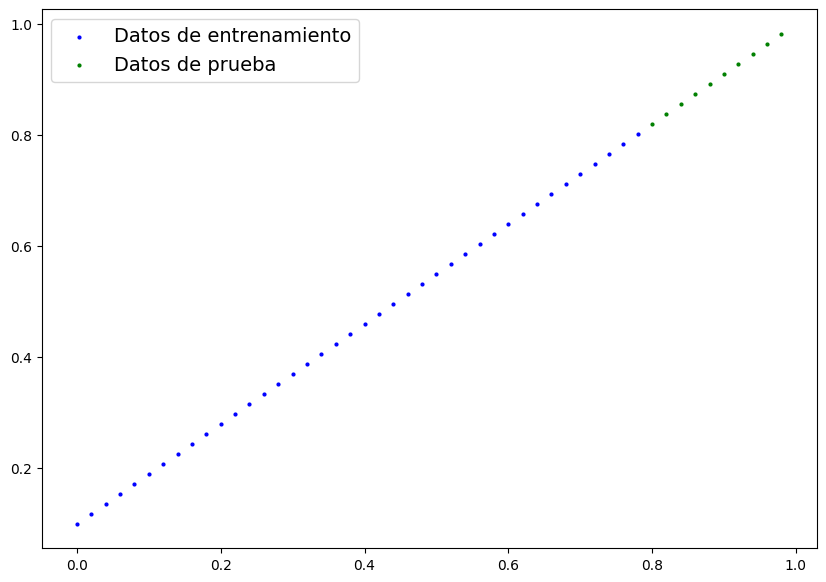

In [7]:
plot_predictions();

### 2. Construcción del Modelo

Lo que hace nuestro modelo es:
* Empezar con valores random (pesos y errores)
* Mira en los datos de entrenamiento y ajusta los valores random a una mejor representación.

Esto lo hace a traves de dos algoritmos principales:
1. Gradiente en descenso.
2. Backpropagation.


In [8]:

#* Creamos una modelo clase de regresión linear
class LinearRegressionModel(nn.Module): #* <- nn.Module es la clase base para todos los módulos de PyTorch
    
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, #* <- empieza con un peso aleatorio y intenta ajustarlo al peso ideal
                                                requires_grad=True, #* <- puede este parámetro ser ajustado por gradiente en descenso?
                                                dtype=torch.float))
    
        self.bias = nn.Parameter(torch.randn(1, #* <- empieza con un bias aleatorio y intenta ajustarlo al bias ideal
                                                requires_grad=True, #* <- puede este parámetro ser ajustado por gradiente en descenso?
                                                dtype=torch.float))
        
        
    def forward(self, x: torch.Tensor) -> torch.Tensor: # X es el input
        return self.weights * x + self.bias # y = mx + b

#### Conceptos básicos para construir modelos con PyTorch

* `torch.nn` - contiene todo para construir grafos computacionales (redes neuronales son considerados grafos computacionales).
* `torch.nn.Parameter` - Guarda tensores que pueden ser usados con `nn.module`. Se puede especificar si estos usan gradiente en descenso con `requires_grad = True`.
* `torch.nn.Module` - Clase base para todos los modules de redes neuronales. 
* `torch.optim` - Contiene varios algoritmos de optimización.
* `def forward()` - Todas las subclases de `nn.module` requieren el método `forward()`, esto define la computación que tomara lugar en paso de los datos.

#### Observando el contenido de nuestro modelo PyTorch

Podemos mirar los parametro sde nuestro modelo usando `.parameters()`

In [9]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [10]:

#* Parámetros listados por nombre
model_0.state_dict() #* <- devuelve un diccionario con los parámetros del modelo

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Haciendo Predicciones usando `torch.inference_model()`

Para mirar el poder de predicción de nuestro modelo, miramos como predice y_test basado en X_test.

Cuando pasamos los datos a traves de nuestro modelo, este va a pasar a traves del método `forward()`.

In [11]:

#* Realizando predicciones con el modelo
with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

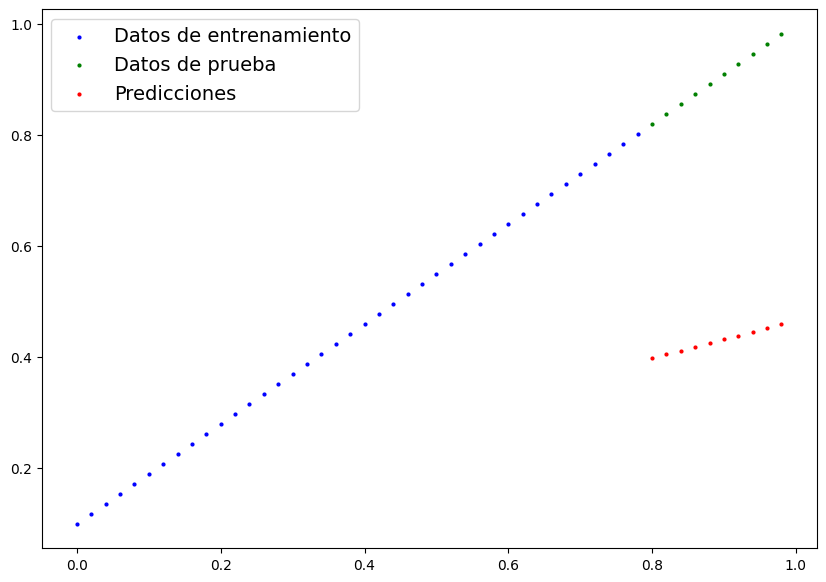

In [12]:
plot_predictions(predictions=y_preds)

### 3. Entrenamiento del Modelo

La idea del entrenamiento del modelo es moverse en algunos *desconocidos* parámetros a algunos parámetros *conocidos*.

Una manera de medir que tan mal esta nuestro modelo es usar las funciones de perdida de PyTorch.

* Nota: la función de perdida puede ser llamada funcion de costo o criterion en diferentes areas.

Cosas que necesitamos para entrenar:

* **Loss Function**: Una función para medir que tan mal esta nuestro modelo con los datos esperados, entre más pequeño sea es mejor.

* **Optimizador**: Toma en cuenta el valor de perdida de un modelo y ajusta los parámetros del modelo para mejorar la función de perdida.

y espercialmente para PyTorch, necesitamos:
* Un entrenamiento en ciclo.
* Un testeo en ciclo.

Se puede mirar mas de como PyTorch maneja la optimización en [torch.optim](https://pytorch.org/docs/stable/optim.html#module-torch.optim) y de las funciones de perdida en [Lost Functions](https://pytorch.org/docs/stable/nn.html#loss-functions)

In [13]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [14]:

#* Configurando una función de perdida
loss_fn = nn.L1Loss() #* <- L1Loss es la función de perdida (absolute error)

#* Configurando un optimizador
optimizer = torch.optim.SGD(params=model_0.parameters(), #* <- parámetros a optimizar
                            lr=0.01) #* <- tasa de aprendizaje 


In [15]:
loss_fn

L1Loss()

#### Construcción de un loop de entrenamiento en PyTorch

Las cosas que necesitamos para un loop de entrenamiento son:
0. Loop a traves de los datos.
1. Forward pass para realizar una predicción de los datos. (Forward Propagation).
2. Calcular la perdida (comparar las predicciones del forward pass con los valores de verdad).
3. Optimizar zero grad.
4. Loss backward - moverse hacia atrás a traves de la red neuronal para calcular los gradientes de cada uno de los parámetros de nuestro modelo con respecto a la función de perdida (backpropagation).
5. Paso de optimización - se ajustan los parámetros del modelo para intentar mejorar el valor de loss.

In [16]:
torch.manual_seed(42)

#* Un epoch es una iteración completa sobre el dataset
epochs = 100

train_loss_values = []
test_loss_values = []
epoch_count = []

#* 0. Loop a traves de los datos
for epoch in range(epochs):
    
    #* Configuramos el modelo en modo entrenamiento
    model_0.train() #* Modo entrenamiento en PyTorch configura todos los parámetros que requieren gradiente.
    
    #* 1. Forward pass
    y_pred = model_0(X_train) #* <- predicciones del modelo
    
    #* 2. Calculamos la perdida
    loss = loss_fn(y_pred, y_train) #* <- calculamos la perdida entre las predicciones y los labels
    
    #* 3. Optimizar el modelo
    optimizer.zero_grad() #* <- pone los gradientes a cero
    
    #* 4. Mejoramos backpropagation en la perdida con respecto a los parámetros del modelo
    loss.backward() #* <- calcula el gradiente de la perdida con respecto a los parámetros del modelo
    
    #* 5. Actualizamos los parámetros del modelo
    optimizer.step() #* <- actualiza los parámetros del modelo
    
    #* Testing
    model_0.eval() #* Apaga el gradient tracking
    
    with torch.inference_mode(): #* <- no se necesita calcular el gradiente
        #* 1. Forward pass
        y_test_pred = model_0(X_test)   #* <- predicciones del modelo
        
        #* 2. Calculamos la perdida
        test_loss = loss_fn(y_test_pred, y_test)
    
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
        #* model state_dict()
        print(model_0.state_dict())

Epoch: 0 | Loss: 0.19351282715797424 | Test loss: 0.4605918824672699
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1373])})
Epoch: 10 | Loss: 0.1328738033771515 | Test loss: 0.36291104555130005
OrderedDict({'weights': tensor([0.3773]), 'bias': tensor([0.2023])})
Epoch: 20 | Loss: 0.10647418349981308 | Test loss: 0.2965734302997589
OrderedDict({'weights': tensor([0.4091]), 'bias': tensor([0.2403])})
Epoch: 30 | Loss: 0.09477243572473526 | Test loss: 0.2532125413417816
OrderedDict({'weights': tensor([0.4359]), 'bias': tensor([0.2598])})
Epoch: 40 | Loss: 0.08884161710739136 | Test loss: 0.22608089447021484
OrderedDict({'weights': tensor([0.4586]), 'bias': tensor([0.2668])})
Epoch: 50 | Loss: 0.08465193212032318 | Test loss: 0.20761175453662872
OrderedDict({'weights': tensor([0.4787]), 'bias': tensor([0.2673])})
Epoch: 60 | Loss: 0.08102920651435852 | Test loss: 0.19523566961288452
OrderedDict({'weights': tensor([0.4971]), 'bias': tensor([0.2633])})
Epoch: 70 | Loss: 0.07753

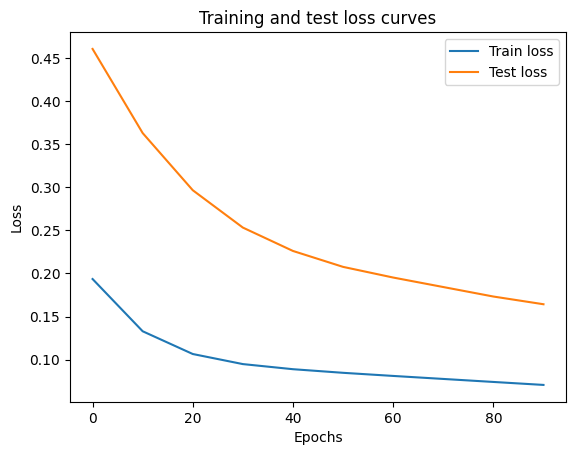

In [17]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

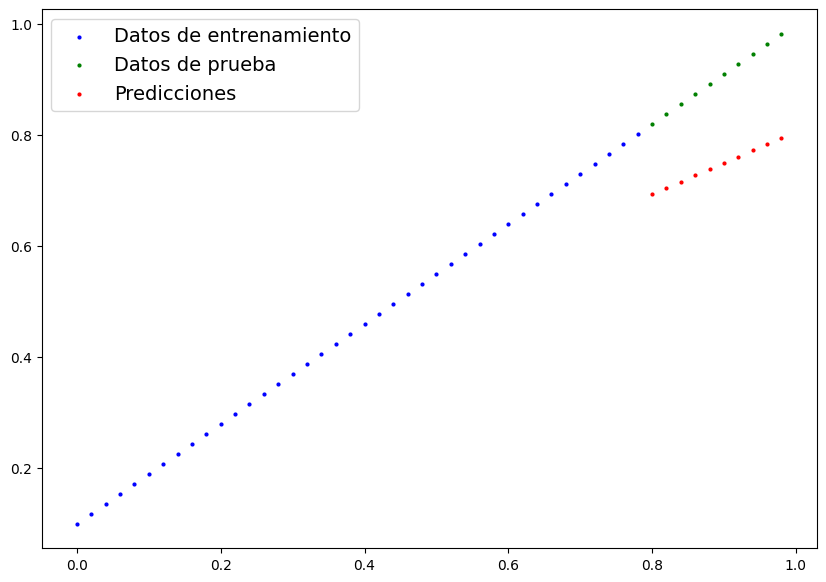

In [18]:
plot_predictions(predictions=y_test_pred)

### Guardar un Modelo en PyTorch

Hay tres métodos para guardar y cargar modelos en PyTorch:
1. `torch.save()`: Guarda un Objeto PyTorch en formato pickle de Python.
2. `torch.load()`: Carga un objeto PyTorch que este guardado.
3. `torch.nn.module.load_state_dict()`: Carga un modelo guardado en un state dictionary

[Save and Loading Models PyTorch](https://pytorch.org/tutorials/beginner/saving_loading_models.html#saving-and-loading-models).

In [20]:

#* Guardando nuestro modelo PyTorch
from pathlib import Path

#* 1. Creamos un directorio para guardar el modelo
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True) #* <- crea el directorio si no existe

#* 2. Creamos un path para guardar el modelo
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME #* <- guarda el modelo en el directorio creado

#* 3. Guardamos el state_dict del modelo
print(f"Guardando el modelo en: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Guardando el modelo en: models\01_pytorch_workflow_model_0.pth


In [29]:

#* Cargando el modelo
#* Para cargar un state_dict tenemos que inicializar una nueva instancia de nuestra clase del modelo

loaded_model_0 = LinearRegressionModel() #* <- inicializamos una nueva instancia del modelo

#* Cargamos el state_dict del modelo_0, para actualizar la nueva instancia
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

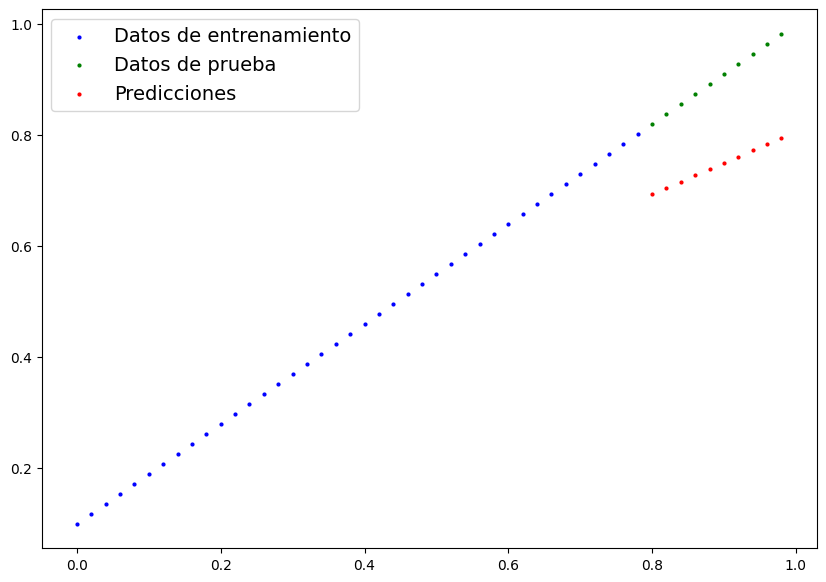

In [31]:
loaded_model_0.state_dict() #* <- devuelve un diccionario con los parámetros del modelo
loaded_model_0.eval() #* <- pone el modelo en modo evaluación
#* Realizando predicciones con el modelo cargado
with torch.inference_mode():
    loaded_model_0_preds = loaded_model_0(X_test)

plot_predictions(predictions=loaded_model_0_preds)